In [1]:
import glob
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress

## Load all generations from their separate files

In [2]:
def load_file(path):
    df = pd.read_csv(path, sep="\t")
    return df

In [3]:
metadata = {
    "GSM252981.txt": {"generation": 1, "dye_swap": False},
    "GSM253167.txt": {"generation": 1, "dye_swap": True},
    "GSM253168.txt": {"generation": 1, "dye_swap": False},
    "GSM253169.txt": {"generation": 1, "dye_swap": False},
    "GSM253170.txt": {"generation": 1, "dye_swap": False},
    "GSM253171.txt": {"generation": 1, "dye_swap": False},
    "GSM253172.txt": {"generation": 1, "dye_swap": False},

    "GSM253175.txt": {"generation": 12, "dye_swap": False},
    "GSM260329.txt": {"generation": 12, "dye_swap": False},
    "GSM253176.txt": {"generation": 12, "dye_swap": True},
    "GSM253177.txt": {"generation": 12, "dye_swap": False},
    "GSM253178.txt": {"generation": 12, "dye_swap": True},
    "GSM253179.txt": {"generation": 12, "dye_swap": False},
    "GSM253180.txt": {"generation": 12, "dye_swap": True},

    "GSM253181.txt": {"generation": 19, "dye_swap": False},
    "GSM253182.txt": {"generation": 19, "dye_swap": True},
    "GSM253183.txt": {"generation": 19, "dye_swap": False},
    "GSM253184.txt": {"generation": 19, "dye_swap": True},
    "GSM253185.txt": {"generation": 19, "dye_swap": False},
    "GSM253186.txt": {"generation": 19, "dye_swap": True},
    "GSM253187.txt": {"generation": 19, "dye_swap": False},

    "GSM253188.txt": {"generation": 8, "dye_swap": True},
    "GSM253189.txt": {"generation": 8, "dye_swap": True},
    "GSM260354.txt": {"generation": 8, "dye_swap": True},
    "GSM253190.txt": {"generation": 8, "dye_swap": False},
    "GSM253191.txt": {"generation": 8, "dye_swap": False},
    "GSM253192.txt": {"generation": 8, "dye_swap": True},
}

Each gene spot on the chip has two fluorescence measurements:

🔴 Red (635 nm) → one condition (often “experimental” or older cells)
🟢 Green (532 nm) → reference condition (often control or baseline)

So each gene is measured like:

“How bright is red compared to green on this exact spot?”

In [4]:
def process_file(path, meta):
    df = pd.read_csv(path, sep="\t")
    df.columns = df.columns.str.strip()
    
    # Filter bad spots
    df = df[df["Flags"] >= 0]
    
    red = df["F635 Median - B635"]
    green = df["F532 Median - B532"]
    
    # Remove invalid values
    mask = (red > 0) & (green > 0)
    df = df[mask]
    
    log2_ratio = np.log2(df["F635 Median - B635"] / df["F532 Median - B532"])
    
    # Fix dye swap
    if meta["dye_swap"]:
        log2_ratio = -log2_ratio
    
    return pd.DataFrame({
        "gene": df["common name"].str.upper().str.strip(),
        "log2_ratio": log2_ratio,
        "generation": meta["generation"]
    })

In [31]:
files = glob.glob("*.txt")

all_data = []

for f in files:
    fname = os.path.basename(f)
    
    if fname not in metadata:
        print(f"Missing metadata for {fname}")
        continue
    
    df = process_file(f, metadata[fname])
    all_data.append(df)

combined = pd.concat(all_data)

In [32]:
print(combined.isna().sum())
print(np.isinf(combined["log2_ratio"]).sum())

gene          0
log2_ratio    0
generation    0
dtype: int64
0


In [35]:
final_df = (combined.groupby(["gene", "generation"])["log2_ratio"].mean().reset_index())

In [36]:
final_df.head(30)

,gene,generation,log2_ratio
0,-,1,-0.993524
1,-,8,0.307986
2,-,12,0.211032
3,-,19,0.060502
4,1-OCT,1,-1.324716
5,1-OCT,8,0.743000
6,1-OCT,12,-0.642948
7,1-OCT,19,-0.476367
8,AAC1,1,-0.067171
9,AAC1,8,0.139086


In [37]:
# 1. Pivot the dataframe so generations become columns
wide_df = final_df.pivot(index='gene', columns='generation', values='log2_ratio')

# 2. Rename columns to include the 'gen_' prefix (e.g., gen_1, gen_8, gen_12, gen_19)
wide_df.columns = [f'gen_{int(col)}' for col in wide_df.columns]

# 3. Reset the index so 'gene' becomes a column again instead of the index
wide_df = wide_df.reset_index()

In [38]:
wide_df.head(10)

,gene,gen_1,gen_8,gen_12,gen_19
0,-,-0.993524,0.307986,0.211032,0.060502
1,1-OCT,-1.324716,0.743000,-0.642948,-0.476367
2,AAC1,-0.067171,0.139086,1.119026,1.029623
3,AAC3,-0.500488,NaN,-1.054824,-1.545272
4,AAD10,NaN,0.477032,NaN,3.131503
5,AAD14|AAD4,-1.283067,0.910202,0.958264,0.586434
6,AAD15|AAD16|AAD3,-1.202183,0.772649,0.302989,0.766160
7,AAD15|AAD3,-0.826898,0.081927,0.199758,0.226206
8,AAD4,-0.735494,0.312949,0.551979,1.179650
9,AAD6,-0.536365,0.051421,-0.024896,0.763573


In [39]:
# Save wide_df to a CSV file. 
# index=False ensures you don't save the numeric row numbers as a separate column.
wide_df.to_csv('generations.csv', index=False)

## Plots

“always decreasing” gene across generations:

log2(g1)>log2(g8)>log2(g12)>log2(g19)

In [9]:
def build_matrix(final_df):
    return final_df.pivot_table(
        index="gene",
        columns="generation",
        values="log2_ratio"
    ).sort_index(axis=1)
def compute_gene_stats(pivot):
    results = []

    x = np.array(pivot.columns)

    for gene, row in pivot.iterrows():
        y = row.values

        if np.any(pd.isna(y)):
            continue

        # 1. slope
        slope = linregress(x, y).slope

        # 2. monotonicity (sign consistency of differences)
        diffs = np.diff(y)
        monotonic_score = np.mean(diffs < 0)  # 1 = always decreasing

        # 3. total change
        total_change = y[-1] - y[0]

        results.append([gene, slope, monotonic_score, total_change])

    return pd.DataFrame(results, columns=[
        "gene", "slope", "monotonicity", "total_change"
    ])
def classify_signatures(stats):
    
    # Strongly decreasing (aging-down signature)
    down = stats[(stats["slope"] < -0.02) &
        (stats["monotonicity"] >= 0.75) &
        (stats["total_change"] < -0.5)
    ]

    # increasing
    # up = stats[(stats["slope"] > 0.01) & (stats["total_change"] > 0.2)]
    up = stats[
    (stats["slope"] > 0.1) &
    (stats["total_change"] > 0.4) &
    (stats["monotonicity"] >= 0.65)]
   


    # Stable genes
    stable = stats[stats["monotonicity"] < 0.6]

    return down, up, stable
def rank_genes(stats):
    stats = stats.copy()

    stats["strength"] = (np.abs(stats["slope"]) + np.abs(stats["total_change"]))

    return stats.sort_values("strength", ascending=False)
def aging_signature_extractor(final_df):

    # 1. matrix
    pivot = build_matrix(final_df)

    # 2. stats
    stats = compute_gene_stats(pivot)
    ####print(stats[stats["slope"] > 0].shape)

    # 3. classification
    down, up, stable = classify_signatures(stats)

    # 4. ranking
    down_ranked = rank_genes(down)
    up_ranked = rank_genes(up)

    return {
        "downregulated": down_ranked,
        "upregulated": up_ranked,
        "stable": stable,
        "all_stats": stats
    }

In [10]:
results = aging_signature_extractor(final_df)

down_genes = results["downregulated"]
up_genes = results["upregulated"]
stable_genes = results["stable"]
print(len(up_genes))

36


In [11]:
def plot_signature_with_labels(df, genes, user_title = "Aging gene signatures"):
    plt.figure(figsize=(10,6))

    for gene in genes:
        subset = df[df["gene"] == gene].sort_values("generation")

        plt.plot(
            subset["generation"],
            subset["log2_ratio"],
            marker="o",
            label=gene
        )



    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Generation")
    plt.ylabel("log2 expression")
    plt.title(user_title)
    plt.xticks([1, 8, 12, 19])  # force integer ticks
    plt.legend()
    plt.show()

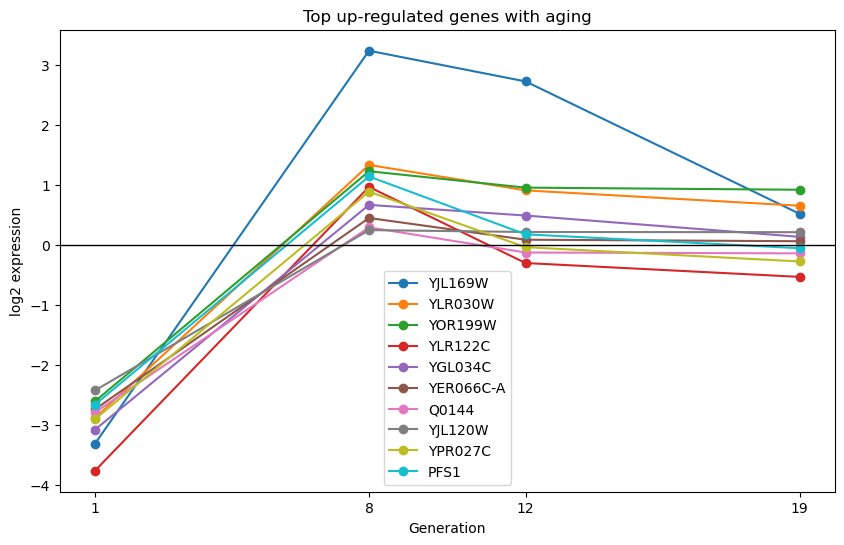

In [12]:
genes = up_genes["gene"].head(10).tolist()

plot_signature_with_labels(final_df, genes, "Top up-regulated genes with aging")

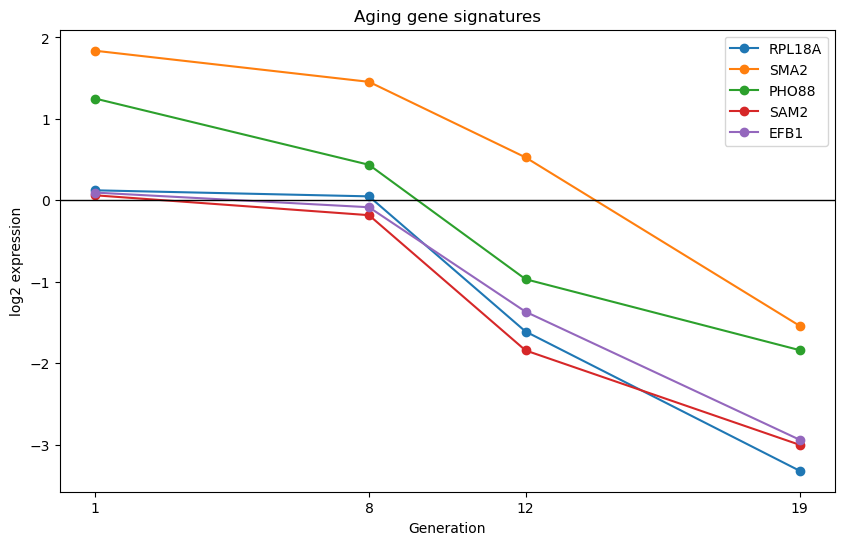

In [13]:
genes = down_genes["gene"].head(5).tolist()

plot_signature_with_labels(final_df, genes)

In [14]:
def plot_gene(df, gene):
    subset = df[df["gene"] == gene]
    
    plt.plot(subset["generation"], subset["log2_ratio"], marker="o")
    plt.title(gene)
    plt.xlabel("Generation")
    plt.ylabel("Log2 expression")
    plt.show()

SNF1: The catalytic subunit

SNF4: The activating subunit , which binds to Snf1p in the absence of glucose.


GAL83, SIP1, SIP2: Alternative regulatory subunits that determine the cellular localization of the Snf1 complex.

REG1, GLC7: Components of a phosphatase complex that regulates Snf1 activity.

In [60]:
glucose_pathway_genes = {"SIP2","REG1"}

glucose_df = final_df[final_df["gene"].isin(glucose_pathway_genes)].copy()

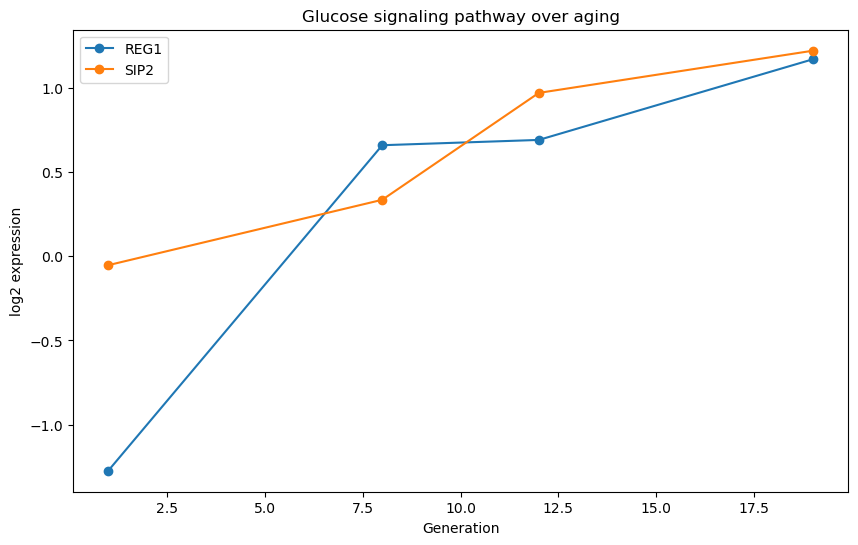

In [61]:
def plot_glucose_genes(df):
    plt.figure(figsize=(10,6))
    
    for gene in df["gene"].unique():
        subset = df[df["gene"] == gene]
        plt.plot(
            subset["generation"],
            subset["log2_ratio"],
            marker="o",
            label=gene
        )
    
    plt.xlabel("Generation")
    plt.ylabel("log2 expression")
    plt.title("Glucose signaling pathway over aging")
    plt.legend()
    plt.show()

plot_glucose_genes(glucose_df)

## To Cytoscape

In [55]:
results = aging_signature_extractor(final_df)
up_genes = results["upregulated"]["gene"]
up_df = pd.DataFrame({"gene": up_genes})

# combined_final = pd.concat([up_df, down_df])

up_df.to_csv(
    "string_genes.txt",
    index=False
)

In [11]:
results = aging_signature_extractor(final_df)
down_genes = results["downregulated"]["gene"]
down_df = pd.DataFrame({"gene": down_genes})

# combined_final = pd.concat([up_df, down_df])

down_df.to_csv(
    "string_genes.txt",
    index=False
)